# Exploratory Data Analysis

In [52]:
import pathlib
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Markdown, display


pl.Config.set_thousands_separator(",")

base_dir = pathlib.Path().resolve().parent
data_dir = pathlib.posixpath.join(base_dir, "data")

# for filename in pathlib.os.listdir(data_dir):
#     print(filename)

events_path = pathlib.posixpath.join(data_dir, "events.csv")
categories_path = pathlib.posixpath.join(data_dir, "category_tree.csv")
item_properties_1_path = pathlib.posixpath.join(data_dir, "item_properties_part1.csv")
item_properties_2_path = pathlib.posixpath.join(data_dir, "item_properties_part2.csv")

In [53]:
df_events = pl.scan_csv(events_path)
df_categories = pl.scan_csv(categories_path)
df_item_properties = pl.concat(
    [pl.scan_csv(item_properties_1_path), pl.scan_csv(item_properties_2_path)]
)

## Overview

In [54]:
display(df_events.describe())

Markdown("""
It is interesting to observe the following facts here:
- total events ~2.7 millions
- total transactionid ~22 thousands
""")

statistic,timestamp,visitorid,event,itemid,transactionid
str,f64,f64,str,f64,str
"""count""",2.756101e6,2.756101e6,"""2,756,101""",2.756101e6,"""22,457"""
"""null_count""",0.0,0.0,"""0""",0.0,"""2,733,644"""
"""mean""","1,436,424,488,348.103516","701,922.883229",null,"234,922.478375",null
"""std""","3,366,312,180.014004","405,687.520809",null,"134,195.425214",null
"""min""","1,430,622,004,384.0",0.0,"""addtocart""",3.0,"""0"""
"""25%""","1,433,478,194,792.0","350,566.0",null,"118,120.0",null
"""50%""","1,436,453,013,599.0","702,060.0",null,"236,067.0",null
"""75%""","1,439,225,105,168.0",1.053437e6,null,"350,715.0",null
"""max""","1,442,545,187,788.0",1.407579e6,"""view""","466,867.0","""9999"""



It is interesting to observe the following facts here:
- total events ~2.7 millions
- total transactionid ~22 thousands


In [55]:
display(
    df_events.with_columns(datetime=pl.col("timestamp").cast(pl.Datetime("ms")))
    .select(
        min_date=pl.col("datetime").min(),
        max_date=pl.col("datetime").max(),
        total_days=(
            (pl.col("datetime").max() - pl.col("datetime").min()) / pl.duration(days=1)
        ).round(1),
    )
    .collect()
)

Markdown("""
Here we learn that we have 138 days of data collection between 2015-05-03 03:00 and 2015-09-18 02:59.
""")

min_date,max_date,total_days
datetime[ms],datetime[ms],f64
2015-05-03 03:00:04.384,2015-09-18 02:59:47.788,138.0



Here we learn that we have 138 days of data collection between 2015-05-03 03:00 and 2015-09-18 02:59.


In [56]:
total_events = df_events.select(pl.len()).collect().item()

display(
    df_events.select(
        unique_visitors=pl.col("visitorid").unique().len(),
        mean_events_per_visitor=total_events / pl.col("visitorid").unique().len(),
        unique_items=pl.col("itemid").unique().len(),
    ).collect()
)

Markdown("""
The number of unique visitors is 1,407,580 with an average of 1.95 events per visitor.
""")

unique_visitors,mean_events_per_visitor,unique_items
u32,f64,u32
"1,407,580",1.958042,"235,061"



The number of unique visitors is 1,407,580 with an average of 1.95 events per visitor.


## Interactions per Visitor

In [57]:
display(
    df_events.group_by("visitorid")
    .agg(pl.len().alias("visitor_interactions"))
    .select(
        min_interactions=pl.col("visitor_interactions").min(),
        max_interactions=pl.col("visitor_interactions").max(),
        mean_interactions=pl.col("visitor_interactions").mean().round(2),
        q25=pl.quantile("visitor_interactions", 0.25),
        q50=pl.quantile("visitor_interactions", 0.50),
        q75=pl.quantile("visitor_interactions", 0.75),
        q90=pl.quantile("visitor_interactions", 0.90),
        q95=pl.quantile("visitor_interactions", 0.95),
        q99=pl.quantile("visitor_interactions", 0.99),
    )
    .collect()
)

Markdown("""
The number of interactions varies a lot per visitor.
- 99% of the visitors have less than 13 events.
- visitors with large number of events like 7,757 are probably bots.
""")

min_interactions,max_interactions,mean_interactions,q25,q50,q75,q90,q95,q99
u32,u32,f64,f64,f64,f64,f64,f64,f64
1,"7,757",1.96,1.0,1.0,2.0,3.0,5.0,13.0



The number of interactions varies a lot per visitor.
- 99% of the visitors have less than 13 events.
- visitors with large number of events like 7,757 are probably bots.


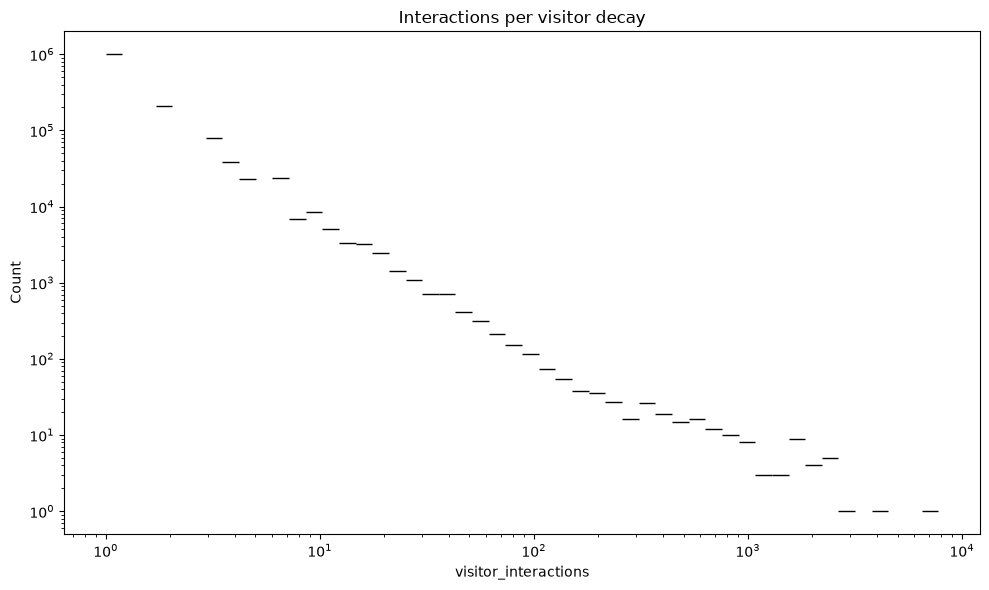

In [58]:
visitor_interactions = (
    df_events.group_by("visitorid")
    .agg(pl.len().alias("visitor_interactions"))
    .select("visitor_interactions")
    .collect()
)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=visitor_interactions,
    x="visitor_interactions",
    bins=50,
    log_scale=(True, True),
)
plt.title("Interactions per visitor decay")
plt.tight_layout()
plt.show()

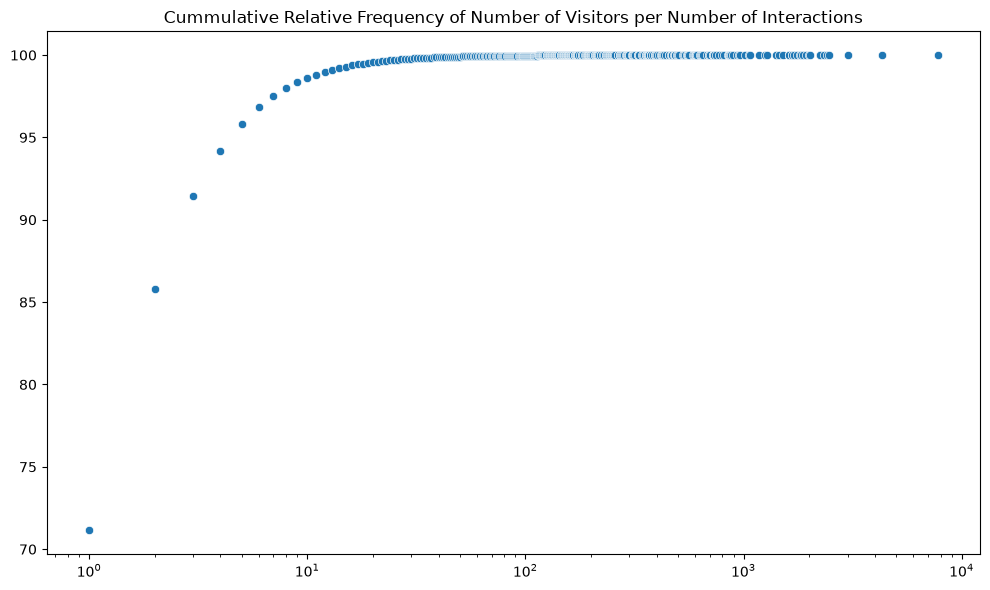

In [59]:
unique_visitors = visitor_interactions.height
number_of_interactions, visitors_counts = np.unique(
    visitor_interactions, return_counts=True
)
cumulative_relative_freq = 100 * np.cumsum(visitors_counts) / unique_visitors

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=number_of_interactions,
    y=cumulative_relative_freq,
)
plt.xscale("log")
plt.title(
    "Cummulative Relative Frequency of Number of Visitors per Number of Interactions"
)
plt.tight_layout()
plt.show()

In [60]:
display(
    df_events.group_by("visitorid")
    .agg(pl.len().alias("interactions"))
    .select(
        up_to_1_pct=100 * (pl.col("interactions") == 1).sum() / pl.len(),
        up_to_1_tot=(pl.col("interactions") == 1).sum(),
        up_to_10_pct=100 * (pl.col("interactions") <= 10).sum() / pl.len(),
        up_to_10_tot=(pl.col("interactions") <= 10).sum(),
        up_to_100_pct=100 * (pl.col("interactions") <= 100).sum() / pl.len(),
        up_to_100_tot=(pl.col("interactions") <= 100).sum(),
        up_to_1000_pct=100 * (pl.col("interactions") <= 1000).sum() / pl.len(),
        up_to_1000_tot=(pl.col("interactions") <= 1000).sum(),
    )
    .collect()
)

Markdown("""
- 71.15% of the unique visitors have only one event.
- 99.99% of the unique visitors have less than 1,000 events.
""")

up_to_1_pct,up_to_1_tot,up_to_10_pct,up_to_10_tot,up_to_100_pct,up_to_100_tot,up_to_1000_pct,up_to_1000_tot
f64,u32,f64,u32,f64,u32,f64,u32
71.154748,"1,001,560",98.608818,"1,387,998",99.971014,"1,407,172",99.997869,"1,407,550"



- 71.15% of the unique visitors have only one event.
- 99.99% of the unique visitors have less than 1,000 events.


In [61]:
df_visitors_interactions = (
    df_events.group_by(["visitorid", "event"])
    .agg(pl.len().alias("interactions"))
    .with_columns(
        event=pl.col("event").map_elements(
            lambda e: {
                "view": "step_1_view",
                "addtocart": "step_2_addtocart",
                "transaction": "step_3_transaction",
            }[e],
            return_dtype=pl.String,
        )
    )
    .group_by("event")
    .agg(
        up_to_1_pct=100 * (pl.col("interactions") == 1).sum() / pl.len(),
        up_to_1_cnt=(pl.col("interactions") == 1).sum(),
        up_to_10_pct=100 * (pl.col("interactions") <= 10).sum() / pl.len(),
        up_to_10_cnt=(pl.col("interactions") <= 10).sum(),
        up_to_100_pct=100 * (pl.col("interactions") <= 100).sum() / pl.len(),
        up_to_100_cnt=(pl.col("interactions") <= 100).sum(),
        up_to_1000_pct=100 * (pl.col("interactions") <= 1000).sum() / pl.len(),
        up_to_1000_cnt=(pl.col("interactions") <= 1000).sum(),
        total=pl.len(),
    )
    .sort("event")
    .collect()
)

display(df_visitors_interactions)

Markdown(f"""
In this output we observe that visitors with:
- one single **view** correspond to {df_visitors_interactions[0, 1]:.2f}% of the unique visitors;
- one single **addtocart** correspond to {df_visitors_interactions[1, 1]:.2f}% of the unique visitors;
- one single **transaction** correspond to {df_visitors_interactions[2, 1]:.2f}% of the unique visitors;
""")

event,up_to_1_pct,up_to_1_cnt,up_to_10_pct,up_to_10_cnt,up_to_100_pct,up_to_100_cnt,up_to_1000_pct,up_to_1000_cnt,total
str,f64,u32,f64,u32,f64,u32,f64,u32,u32
"""step_1_view""",71.766491,"1,007,730",98.738337,"1,386,463",99.973508,"1,403,807",99.997935,"1,404,150","1,404,179"
"""step_2_addtocart""",75.942421,"28,647",98.841525,"37,285",99.923122,"37,693",100.0,"37,722","37,722"
"""step_3_transaction""",78.018602,"9,143",98.822425,"11,581",99.872003,"11,704",100.0,"11,719","11,719"



In this output we observe that visitors with:
- one single **view** correspond to 71.77% of the unique visitors;
- one single **addtocart** correspond to 75.94% of the unique visitors;
- one single **transaction** correspond to 78.02% of the unique visitors;


In [62]:
unique_visitors = df_events.select(pl.col("visitorid").unique().len()).collect().item()

min_events = [1, 3, 5, 10]
max_events = [300, 500, 1000]

visitors_dist = np.ndarray((len(min_events), len(max_events)), dtype=np.float32)

for i, min_iters in enumerate(min_events):
    for j, max_iters in enumerate(max_events):
        visitors_dist[i, j] = (
            df_events.group_by("visitorid")
            .agg(pl.len().alias("interactions"))
            .select(
                (
                    (pl.col("interactions") >= min_iters)
                    & (pl.col("interactions") <= max_iters)
                ).sum()
            )
            .collect()
            .item()
        )

In [63]:
visitors_slice_pct = 100 * visitors_dist / unique_visitors

display(
    pl.DataFrame(
        np.concat([np.array(min_events).reshape(-1, 1), visitors_slice_pct], axis=1),
        [("min_events", pl.Int8)]
        + list(map(lambda m: (f"up to {m}", pl.Float32), max_events)),
    )
)

Markdown("""
This matrix allow us to have a picture of the percentage of the unique visitors we will be including in our analysis if we remove those with too few events and those with too many.

If we follow this path, the sweat spot must be to keep visitors with at least 3 events and at most 300 events, resulting in 14.20% of the unique visitors.
""")

min_events,up to 300,up to 500,up to 1000
i8,f32,f32,f32
1,99.990555,99.994667,99.997871
3,14.201324,14.205444,14.208642
5,5.789156,5.793276,5.796474
10,1.641683,1.645803,1.649



This matrix allow us to have a picture of the percentage of the unique visitors we will be including in our analysis if we remove those with too few events and those with too many.

If we follow this path, the sweat spot must be to keep visitors with at least 3 events and at most 300 events, resulting in 14.20% of the unique visitors.


## User Sessions

In [64]:
events = {
    "view": 1,
    "addtocart": 2,
    "transaction": 3,
}

df_sessions = (
    df_events.sort(["visitorid", "timestamp"])
    .with_columns(
        time_diff=pl.col("timestamp").diff().over("visitorid"),
        event_id=pl.col("event").replace_strict(events),
    )
    .with_columns(
        is_new_session=(
            (pl.col("time_diff").is_null()) | (pl.col("time_diff") > 1_800_000)
        ).cast(pl.Int32)
    )
    .with_columns(session_id=pl.col("is_new_session").cum_sum().over("visitorid"))
    .with_columns(
        session_event_id=pl.col("timestamp").rank().over(["visitorid", "session_id"])
    )
    .with_columns(
        history=pl.concat_list("timestamp", "itemid", "event_id")
        .implode()
        .over(["visitorid", "session_id"])
        .list.head(pl.col("session_event_id") - 1)
    )
    .filter(pl.col("history").list.len() > 0)
    .collect()
)

display(df_sessions.head(5))

Markdown("""
- We define a session as a sequence of events from the same visitor within a 30 minutes window.
- Each visitor can have multiple sessions identified by `sessionid`.
- Each line is still an event, but is is now part of a session.
- Using the `history` column we can learn the previous items the visitor interacted with before interacting with the current one.
""")

timestamp,visitorid,event,itemid,transactionid,time_diff,event_id,is_new_session,session_id,session_event_id,history
i64,i64,str,i64,str,i64,i64,i32,i32,f64,list[list[i64]]
"1,442,004,759,591",0,"""view""","357,564",null,"170,152",1,0,1,2.0,"[[1,442,004,589,439, 285,930, 1]]"
"1,442,004,917,175",0,"""view""","67,045",null,"157,584",1,0,1,3.0,"[[1,442,004,589,439, 285,930, 1], [1,442,004,759,591, 357,564, 1]]"
"1,438,970,013,790",2,"""view""","325,215",null,"109,223",1,0,1,2.0,"[[1,438,969,904,567, 325,215, 1]]"
"1,438,970,212,664",2,"""view""","259,884",null,"198,874",1,0,1,3.0,"[[1,438,969,904,567, 325,215, 1], [1,438,970,013,790, 325,215, 1]]"
"1,438,970,468,920",2,"""view""","216,305",null,"256,256",1,0,1,4.0,"[[1,438,969,904,567, 325,215, 1], [1,438,970,013,790, 325,215, 1], [1,438,970,212,664, 259,884, 1]]"



- We define a session as a sequence of events from the same visitor within a 30 minutes window.
- Each visitor can have multiple sessions identified by `sessionid`.
- Each line is still an event, but is is now part of a session.
- Using the `history` column we can learn the previous items the visitor interacted with before interacting with the current one.


In [65]:
total_unique_visitors = (
    df_events.select(pl.col("visitorid").unique().len()).collect().item()
)
total_unique_items = df_events.select(pl.col("itemid").unique().len()).collect().item()

display(
    df_sessions.select(
        unique_visitors=pl.col("visitorid").unique().len(),
        unique_visitors_pct_from_total=100
        * pl.col("visitorid").unique().len()
        / total_unique_visitors,
        unique_items=pl.col("itemid").unique().len(),
        unique_items_pct_from_total=100
        * pl.col("itemid").unique().len()
        / total_unique_items,
        mean_hist_len=pl.col("history").list.len().mean(),
    )
)

Markdown("""
Pursuing this sessionized view of the events we keep 315,568 unique visitors, which corresponds to 22.41% of all unique visitors.

It is a substantial gain compared to removing those with at least and at most a certain number of interactions.
""")

unique_visitors,unique_visitors_pct_from_total,unique_items,unique_items_pct_from_total,mean_hist_len
u32,f64,u32,f64,f64
"315,568",22.419188,"117,940",50.17421,6.769737



Pursuing this sessionized view of the events we keep 315,568 unique visitors, which corresponds to 22.41% of all unique visitors.

It is a substantial gain compared to removing those with at least and at most a certain number of interactions.


## Items

### Categories

In [66]:
def build_ancestors_path(category_id: pl.Int32) -> pl.List:
    # global df_categories: pl.DataFrame
    ancestors = []

    current_category = category_id
    current_parent = (
        df_categories.filter(pl.col("categoryid") == current_category)
        .select("parentid")
        .collect()
    )
    while not current_parent.is_empty():
        parent = current_parent.item()
        if parent is None:
            break
        ancestors.append(parent)
        current_category = parent
        current_parent = (
            df_categories.filter(pl.col("categoryid") == current_category)
            .select("parentid")
            .collect()
        )

    return ancestors


df_categories_full = (
    df_categories.with_columns(
        path=pl.col("categoryid").map_elements(
            build_ancestors_path, return_dtype=pl.List(pl.Int32)
        )
    )
    .select(["categoryid", "path"])
    .collect()
)

display(df_categories_full)

Markdown("""
Even though categories are given by their ids only, we can buid the ancestor path of each category.
""")

categoryid,path
i64,list[i32]
"1,016","[213, 1,299, 1,532]"
809,"[169, 1,257, 395]"
570,"[9, 351, 653]"
"1,691","[885, 1,579]"
536,"[1,691, 885, 1,579]"
…,…
49,"[1,125, 113, 1,532]"
"1,112","[630, 679]"
"1,336","[745, 540, 140]"



Even though categories are given by their ids only, we can buid the ancestor path of each category.


In [67]:
display(
    df_categories_full.select(
        pl.col("path").list.len().min().alias("min_depth"),
        pl.col("path").list.len().max().alias("max_depth"),
    )
)

min_depth,max_depth
u32,u32
0,5


### Properties

In [68]:
display(df_item_properties.describe())

Markdown("""
This is the largest dataset with ~20 millions of rows.
""")

statistic,timestamp,itemid,property,value
str,f64,f64,str,str
"""count""",2.0275902e7,2.0275902e7,"""20,275,902""","""20,275,902"""
"""null_count""",0.0,0.0,"""0""","""0"""
"""mean""","1,435,156,943,682.880371","233,390.432525",null,null
"""std""","3,327,797,780.703904","134,845.230668",null,null
"""min""","1,431,226,800,000.0",0.0,"""0""","""0"""
"""25%""","1,432,436,400,000.0","116,516.0",null,null
"""50%""","1,433,646,000,000.0","233,483.0",null,null
"""75%""","1,437,879,600,000.0","350,304.0",null,null
"""max""","1,442,113,200,000.0","466,866.0","""categoryid""","""nInfinity"""



This is the largest dataset with ~20 millions of rows.


In [69]:
display(
    df_item_properties.select(
        distinct_categories=pl.col("property").unique().len(),
    ).collect()
)

Markdown("""
We have only 1,104 distinct categories.
""")

distinct_categories
u32
"1,104"



We have only 1,104 distinct categories.


In [70]:
display(
    df_item_properties.select(
        # distinct_categories_int=pl.col("property").unique().cast(pl.Int32, strict=False).sort(),
        distinct_categories=pl.col("property").unique().sort(),
    ).collect()
)

Markdown("""
Their names are just an integer, except for 2: **available** and **categoryid**

This is good since we can avoid recommending unavailable items if we have that information.

We can also use this to join this information with the categories dataset.
""")

distinct_categories
str
"""0"""
"""1"""
"""10"""
"""100"""
"""1000"""
…
"""997"""
"""998"""
"""999"""



Their names are just an integer, except for 2: **available** and **categoryid**

This is good since we can avoid recommending unavailable items if we have that information.

We can also use this to join this information with the categories dataset.


In [71]:
display(
    df_item_properties.filter(~pl.col("property").is_in(["categoryid", "available"]))
    .with_columns(
        property=pl.col("property"),
        value_original=pl.col("value"),
        value_encoded=pl.col("value").rank("dense").over("property").cast(pl.UInt32),
    )
    .select(["property", "value_encoded", "value_original"])
    .unique()
    .sort(["property", "value_encoded"])
    # .group_by("property")
    # .agg(
    #     values_encoded=pl.col("value_encoded").unique().sort()
    # )
    # .with_columns(
    #     max_val=pl.col("values_encoded").list.max()
    # )
    # .sort(by="max_val", descending=True)
    # .limit(10)
    .collect()  # .describe()
)

Markdown("""
Since the values are also encoded, let's add an extra encoding and make it simpler.
""")

property,value_encoded,value_original
str,u32,str
"""0""",1,"""1008741 561431 508431"""
"""0""",2,"""1008741 855334"""
"""0""",3,"""1026244 358960"""
"""0""",4,"""1031785 703294"""
"""0""",5,"""1066831 999832 632043"""
…,…,…
"""998""",4,"""n48.000"""
"""998""",5,"""n96.000"""
"""999""",1,"""1116693"""



Since the values are also encoded, let's add an extra encoding and make it simpler.


In [72]:
display(
    df_item_properties.group_by("itemid")
    .agg(pl.col("property").unique().len().alias("properties_len"))
    .select(
        min_properties=pl.col("properties_len").min(),
        max_properties=pl.col("properties_len").max(),
        mean_properties=pl.col("properties_len").mean(),
        q25=pl.quantile("properties_len", 0.25),
        q50=pl.quantile("properties_len", 0.50),
        q75=pl.quantile("properties_len", 0.75),
        q90=pl.quantile("properties_len", 0.90),
        q99=pl.quantile("properties_len", 0.99),
    )
    .collect()
)

Markdown("""
The distribution of the properties per item varies a lot:
- certain items have only 12 unique properties...
- meanwhile, other items have 59 unique properties!
- have a mean of 28 and a median of 27 properties per item.
""")

min_properties,max_properties,mean_properties,q25,q50,q75,q90,q99
u32,u32,f64,f64,f64,f64,f64,f64
12,59,28.782466,24.0,27.0,31.0,41.0,51.0



The distribution of the properties per item varies a lot:
- certain items have only 12 unique properties...
- meanwhile, other items have 59 unique properties!
- have a mean of 28 and a median of 27 properties per item.


In [73]:
display(
    df_item_properties
    # .sort(["itemid", "timestamp"])
    .group_by(["itemid", "timestamp"], maintain_order=True)
    .agg(
        available=pl.col("value").filter(pl.col("property").eq("available")),
        categoryid=pl.col("value").filter(pl.col("property").eq("categoryid")),
        properties_n_values=pl.concat_list([pl.col("property"), pl.col("value")])
        .filter(~pl.col("property").is_in(["categoryid", "available"]))
        .list.join("="),
    )
    .select(
        itemid=pl.col("itemid"),
        timestamp=pl.col("timestamp"),
        properties_n_values=pl.col("properties_n_values").list.join(","),
        available=pl.col("available").list.first().fill_null("2").cast(pl.Int32),
        categoryid=pl.col("categoryid").list.first().fill_null("-1").cast(pl.Int32),
    )
    .limit(10)
    .collect()
    .head(10)
)

Markdown("""
This transformation allow us to use the properties valid for an itemid at a given moment in time.
         
It also becomes possible to join this information with the categories dataset when the `categoryid` is available.
""")

itemid,timestamp,properties_n_values,available,categoryid
i64,i64,str,i32,i32
"460,429","1,435,460,400,000","""884=n12288.000 628176 n9216.00…",2,"1,338"
"206,783","1,441,508,400,000","""888=1116713 960601 n277.200,79…",1,-1
"395,014","1,439,089,200,000","""400=n552.000 639502 n720.000 4…",2,-1
"59,481","1,431,226,800,000","""790=n15360.000,1032=769062,764…",1,498
"156,781","1,431,831,600,000","""917=828513,790=n32520.000,776=…",2,"1,356"
"285,026","1,436,065,200,000","""790=n70560.000""",0,-1
"89,534","1,434,250,800,000","""213=1121373""",2,-1
"264,312","1,431,831,600,000","""6=319724,227=319724,917=141325…",0,-1
"229,370","1,433,646,000,000","""202=1330310,807=140286,364=804…",2,-1



This transformation allow us to use the properties valid for an itemid at a given moment in time.

It also becomes possible to join this information with the categories dataset when the `categoryid` is available.


In [74]:
max_properties = (
    df_item_properties.group_by("itemid")
    .agg(pl.col("property").unique().len().alias("properties_len"))
    .select(pl.col("properties_len").max())
    .collect()
    .item()
)

display(f"Maximum number of properties in an item: {max_properties}")

'Maximum number of properties in an item: 59'

In [86]:
display(
    df_item_properties.select(
        pl.col("property").unique().cast(pl.Int32, strict=False).len()
    ).collect()
)

property
u32
"1,104"


In [107]:
df_encoded_values = pl.concat(
    [
        df_item_properties.filter(pl.col("property").is_in(["available"]))
        .with_columns(
            property=pl.col("property"),
            value_original=pl.col("value"),
            value_encoded=pl.col("value").cast(pl.UInt32, strict=False),
        )
        .select(["property", "value_encoded", "value_original"])
        .unique()
        .sort(["property", "value_encoded"]),
        df_item_properties.filter(pl.col("property").is_in(["categoryid"]))
        .with_columns(
            property=pl.col("property"),
            value_original=pl.col("value"),
            value_encoded=pl.col("value").cast(pl.UInt32, strict=False),
        )
        .select(["property", "value_encoded", "value_original"])
        .unique()
        .sort(["property", "value_encoded"]),
        df_item_properties.filter(
            ~pl.col("property").is_in(["categoryid", "available"])
        )
        .with_columns(
            property=pl.col("property"),
            value_original=pl.col("value"),
            value_encoded=pl.col("value")
            .rank("dense")
            .over("property")
            .cast(pl.UInt32),
        )
        .select(["property", "value_encoded", "value_original"])
        .unique()
        .sort(["property", "value_encoded"]),
    ]
)

display(df_encoded_values.collect())

property,value_encoded,value_original
str,u32,str
"""available""",0,"""0"""
"""available""",1,"""1"""
"""categoryid""",0,"""0"""
"""categoryid""",1,"""1"""
"""categoryid""",2,"""2"""
…,…,…
"""998""",4,"""n48.000"""
"""998""",5,"""n96.000"""
"""999""",1,"""1116693"""


In [76]:
df_encoded_values.collect().head(10)

property,value_encoded,value_original
str,u32,str
"""0""",1,"""1008741 561431 508431"""
"""0""",2,"""1008741 855334"""
"""0""",3,"""1026244 358960"""
"""0""",4,"""1031785 703294"""
"""0""",5,"""1066831 999832 632043"""
"""0""",6,"""1103829 123296"""
"""0""",7,"""1117759"""
"""0""",8,"""1157821 123296"""
"""0""",9,"""1175668 1057186 115688"""


In [112]:
total_mingled_properties = (
    df_item_properties.filter(~pl.col("property").is_in(["categoryid", "available"]))
    .select(pl.col("property").unique().cast(pl.Int32, strict=False).len())
    .collect()
    .item()
)

display(
    f"Total number of properties except categoryid and available: {total_mingled_properties}"
)

display(
    df_item_properties.filter(pl.col("itemid").eq(156781))
    .join(
        df_encoded_values,
        left_on=["property", "value"],
        right_on=["property", "value_original"],
        how="left",
    )
    .sort(["itemid", "timestamp"])
    .pivot(
        on="property",
        index=["itemid", "timestamp"],
        values="value_encoded",
        on_columns=["available", "categoryid"]
        + [str(i) for i in range(total_mingled_properties)],
    )
    .rename({"itemid": "item_id", "categoryid": "category_id"})
    .with_columns(
        available=pl.col("available").fill_null(2),
        category_id=pl.col("category_id").fill_null(-1),
    )
    .rename({str(i): f"property_{i}" for i in range(total_mingled_properties)})
    .collect()
)

'Total number of properties except categoryid and available: 1102'

item_id,timestamp,available,category_id,property_0,property_1,property_2,property_3,property_4,property_5,property_6,property_7,property_8,property_9,property_10,property_11,property_12,property_13,property_14,property_15,property_16,property_17,property_18,property_19,property_20,property_21,property_22,property_23,property_24,property_25,property_26,property_27,property_28,property_29,property_30,property_31,property_32,…,property_1065,property_1066,property_1067,property_1068,property_1069,property_1070,property_1071,property_1072,property_1073,property_1074,property_1075,property_1076,property_1077,property_1078,property_1079,property_1080,property_1081,property_1082,property_1083,property_1084,property_1085,property_1086,property_1087,property_1088,property_1089,property_1090,property_1091,property_1092,property_1093,property_1094,property_1095,property_1096,property_1097,property_1098,property_1099,property_1100,property_1101
i64,i64,u32,i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"156,781","1,439,089,200,000",2,891,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"156,781","1,431,831,600,000",2,"1,356",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"156,781","1,434,250,800,000",2,"1,356",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"156,781","1,441,508,400,000",2,891,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"156,781","1,440,903,600,000",2,891,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"156,781","1,432,436,400,000",2,"1,356",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"156,781","1,435,460,400,000",0,"1,356",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null